# Group 3: Naive Bayes Spam Classification (Colab Ready)

This notebook builds a spam detector for SMS messages using **Naive Bayes**.

## What Problem Are We Solving?

We have a binary classification task:
- Class 0: Ham (not spam)
- Class 1: Spam

Goal: Given an SMS message, predict whether it is spam or ham.

## Bayes Theorem and Naive Bayes 

Bayes theorem updates probability after seeing evidence:

$$P(y \mid x) = \frac{P(x \mid y)P(y)}{P(x)}$$

For text classification, Naive Bayes applies this idea with a simplifying assumption:
- Words are treated as conditionally independent given the class.

In practice, the model compares scores for spam vs ham and predicts the higher one:

$$\log P(y \mid x) \propto \log P(y) + \sum_i x_i \log P(w_i \mid y)$$

where:
- $P(y)$ is the class prior (base rate of spam or ham)
- $P(w_i \mid y)$ is how strongly token $w_i$ is associated with class $y$
- $x_i$ is the token weight (from TF-IDF in this notebook)

## Why Naive Bayes Here?

- Fast to train and run
- Works very well on text classification baselines
- Lightweight and explainable 

## Success Metrics 

Primary metrics for presentation:
- Accuracy
- Precision
- Recall

Support metrics:
- F1-score
- ROC-AUC

In [1]:
# Colab-friendly setup: keep core scientific stack untouched to avoid ABI conflicts.
!pip -q install "pandas==2.2.2" datasets ipywidgets wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 15.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.2 MB/s eta 0:00:00


In [13]:
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
SEED = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 140)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Data Collection

We load one fixed dataset directly from Hugging Face: `ucirvine/sms_spam`.

Then we standardize labels into binary values: spam = 1 and ham = 0.

In [14]:
def normalize_labels(label_series):
    """Convert many possible label formats into binary: spam=1, ham=0."""
    s = label_series.astype(str).str.lower().str.strip()

    if s.isin(["0", "1"]).all():
        return s.astype(int)

    def map_label(x):
        if x in {"ham", "not spam", "legit", "legitimate", "0", "no", "false"}:
            return 0
        if x in {"spam", "1", "yes", "true", "junk"}:
            return 1
        if "ham" in x:
            return 0
        if ("spam" in x) and ("not" not in x):
            return 1
        return np.nan

    y = s.apply(map_label)
    return y


def load_spam_dataframe():
    ds_name = "ucirvine/sms_spam"
    split_name = "train"
    ds = load_dataset(ds_name, split=split_name)
    df = ds.to_pandas()

    text_col = next((c for c in ["text", "sms", "message", "body", "content"] if c in df.columns), None)
    label_col = next((c for c in ["label", "spam", "target", "category", "class"] if c in df.columns), None)

    if not text_col or not label_col:
        raise ValueError(f"Could not find expected text/label columns in {ds_name}.")

    out = df[[text_col, label_col]].copy()
    out.columns = ["text", "label_raw"]
    out["label"] = normalize_labels(out["label_raw"])
    out = out.dropna(subset=["text", "label"]).copy()
    out["text"] = out["text"].astype(str).str.strip()
    out = out[out["text"].str.len() > 0]
    out["label"] = out["label"].astype(int)

    print(f"Loaded dataset from Hugging Face: {ds_name}")
    return out[["text", "label"]]


df = load_spam_dataframe()
print(f"Dataset shape: {df.shape}")
display(df.head())
print(df['label'].value_counts().rename(index={0: 'ham', 1: 'spam'}))

Loaded dataset from Hugging Face: ucirvine/sms_spam
Dataset shape: (5574, 2)


,text,label
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply ...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives around here though",0


label
ham     4827
spam     747
Name: count, dtype: int64


## Step 3: Exploratory Data Analysis (EDA)

We summarize key statistics, inspect class balance, and visualize text length distributions (a useful signal in spam detection).

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
char_length,5574.0,80.443488,59.841746,2.0,36.0,61.0,122.0,910.0
word_count,5574.0,15.591676,11.390454,1.0,7.0,12.0,23.0,171.0


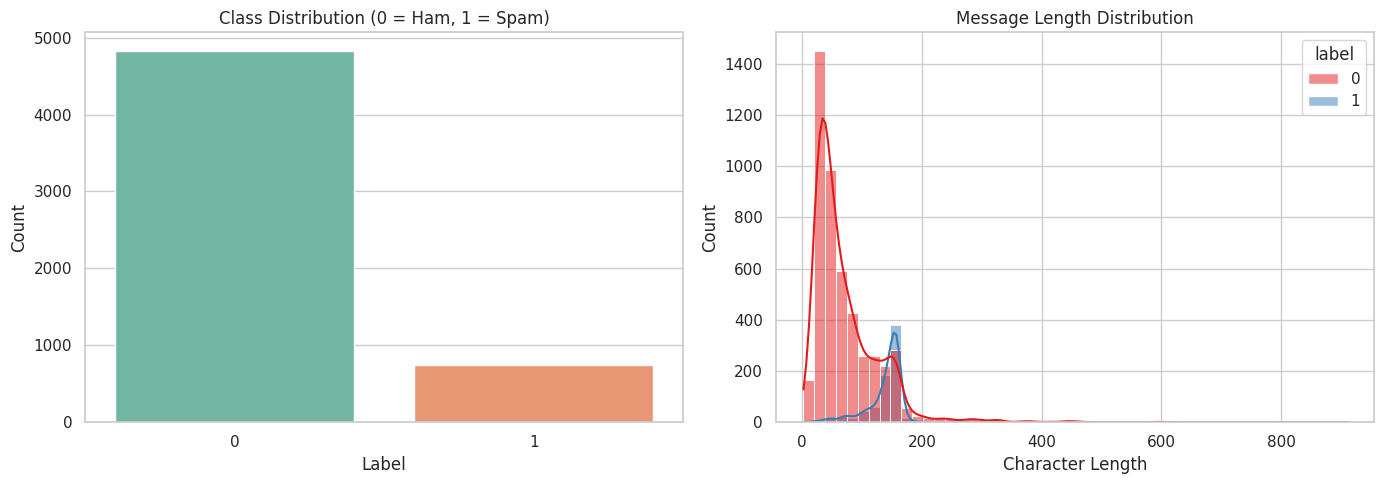

In [4]:
df['char_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("Summary statistics:")
display(df[['char_length', 'word_count']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='label', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution (0 = Ham, 1 = Spam)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

sns.histplot(data=df, x='char_length', hue='label', bins=50, kde=True, ax=axes[1], palette='Set1')
axes[1].set_title('Message Length Distribution')
axes[1].set_xlabel('Character Length')

plt.tight_layout()
plt.show()

## Step 4: Data Cleaning & Preprocessing

We clean text by lowercasing, removing URLs, stripping punctuation/non-letters, and normalizing spaces.

For features, we use **TF-IDF** so Naive Bayes can learn token importance efficiently.

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

display(df[['text', 'clean_text', 'label']].head(8))
print(f"Rows after cleaning: {len(df)}")

,text,clean_text,label
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply ...,free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply over s,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,"Nah I don't think he goes to usf, he lives around here though",nah i don t think he goes to usf he lives around here though,0
5,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £...",freemsg hey there darling it s been week s now and no word back i d like some fun you up for it still tb ok xxx std chgs to send to rcv,1
6,Even my brother is not like to speak with me. They treat me like aids patent.,even my brother is not like to speak with me they treat me like aids patent,0
7,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy...,as per your request melle melle oru minnaminunginte nurungu vettam has been set as your callertune for all callers press to copy your fr...,0


Rows after cleaning: 5571


## Step 5: Train / Validation / Test Split

We use a stratified split to preserve class balance:
- Train: 70%
- Validation: 15%
- Test: 15%

In [6]:
X = df['clean_text']
y = df['label']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15 / 0.85), random_state=SEED, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 3899
Validation size: 836
Test size: 836


## Step 6: Model Selection (Naive Bayes Candidates)

We compare two Naive Bayes variants using grid search:
- MultinomialNB
- ComplementNB

Both are popular for text classification tasks.

In [7]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb', MultinomialNB())
])

param_grid = [
    {
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'tfidf__min_df': [1, 2, 3],
        'nb': [MultinomialNB()],
        'nb__alpha': [0.1, 0.5, 1.0]
    },
    {
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'tfidf__min_df': [1, 2, 3],
        'nb': [ComplementNB()],
        'nb__alpha': [0.1, 0.5, 1.0]
    }
]

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print('Best parameters:')
print(grid.best_params_)
print(f"Best CV F1-score: {grid.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters:
{'nb': MultinomialNB(), 'nb__alpha': 0.1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best CV F1-score: 0.9350


## Step 7: Train The Model

GridSearchCV already trained all candidate models and selected the best one.

Now we check validation performance before final testing.

In [8]:
def evaluate_split(model, X_split, y_split, split_name='Split'):
    pred = model.predict(X_split)
    prob = model.predict_proba(X_split)[:, 1]

    metrics = {
        'split': split_name,
        'accuracy': accuracy_score(y_split, pred),
        'precision': precision_score(y_split, pred, zero_division=0),
        'recall': recall_score(y_split, pred, zero_division=0),
        'f1': f1_score(y_split, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_split, prob)
    }
    return metrics, pred, prob

val_metrics, y_val_pred, y_val_prob = evaluate_split(best_model, X_val, y_val, split_name='Validation')
display(pd.DataFrame([val_metrics]).set_index('split').round(4))
print('Validation classification report:')
print(classification_report(y_val, y_val_pred, digits=4))

,accuracy,precision,recall,f1,roc_auc
split,,,,,
Validation,0.9904,0.9727,0.9554,0.964,0.9959


Validation classification report:
              precision    recall  f1-score   support

           0     0.9931    0.9959    0.9945       724
           1     0.9727    0.9554    0.9640       112

    accuracy                         0.9904       836
   macro avg     0.9829    0.9756    0.9792       836
weighted avg     0.9904    0.9904    0.9904       836



## Step 8: Model Evaluation On Test Set

We now evaluate the selected model on unseen test data with relevant metrics and visualizations.

,accuracy,precision,recall,f1,roc_auc
split,,,,,
Test,0.9773,0.9604,0.8661,0.9108,0.9885


Test classification report:
              precision    recall  f1-score   support

           0     0.9796    0.9945    0.9870       724
           1     0.9604    0.8661    0.9108       112

    accuracy                         0.9773       836
   macro avg     0.9700    0.9303    0.9489       836
weighted avg     0.9770    0.9773    0.9768       836



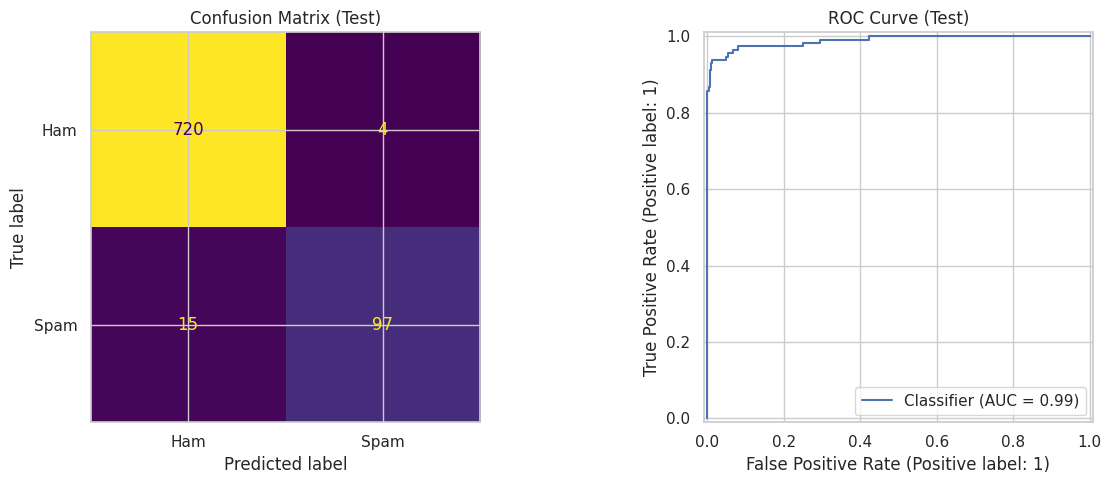

In [9]:
test_metrics, y_test_pred, y_test_prob = evaluate_split(best_model, X_test, y_test, split_name='Test')
display(pd.DataFrame([test_metrics]).set_index('split').round(4))

print('Test classification report:')
print(classification_report(y_test, y_test_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Test)')

RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[1])
axes[1].set_title('ROC Curve (Test)')

plt.tight_layout()
plt.show()

## Model Interpretability (Connecting Back to Naive Bayes)

At this stage, we already trained and evaluated the model. Now we show **why** the model predicts spam or ham.

Recall the Naive Bayes scoring idea used throughout:

$$\log P(y \mid x) \propto \log P(y) + \sum_i x_i \log P(w_i \mid y)$$

The next cells visualize this by:
- listing top spam-indicative and ham-indicative tokens
- showing token-level contributions for a single message

So this section is a practical explanation of the same Naive Bayes formula introduced at the top.

In [10]:
# Show top indicative words for spam vs ham based on learned log-probabilities.
vectorizer = best_model.named_steps['tfidf']
nb_model = best_model.named_steps['nb']
feature_names = np.array(vectorizer.get_feature_names_out())

class_order = list(nb_model.classes_)
ham_idx = class_order.index(0)
spam_idx = class_order.index(1)

delta = nb_model.feature_log_prob_[spam_idx] - nb_model.feature_log_prob_[ham_idx]

top_spam_idx = np.argsort(delta)[-20:][::-1]
top_ham_idx = np.argsort(delta)[:20]

top_spam_words = pd.DataFrame({
    'token': feature_names[top_spam_idx],
    'spam_minus_ham_log_prob': delta[top_spam_idx]
})

top_ham_words = pd.DataFrame({
    'token': feature_names[top_ham_idx],
    'spam_minus_ham_log_prob': delta[top_ham_idx]
})

print('Top spam-indicative tokens:')
display(top_spam_words)
print('Top ham-indicative tokens:')
display(top_ham_words)

Top spam-indicative tokens:


,token,spam_minus_ham_log_prob
0,claim,5.645420
1,prize,5.467568
2,ppm,4.983729
3,tone,4.983376
4,guaranteed,4.964221
5,cs,4.893026
6,pobox,4.740810
7,ringtone,4.649370
8,po box,4.624997
9,awarded,4.599805


Top ham-indicative tokens:


,token,spam_minus_ham_log_prob
0,gt,-4.807643
1,lt,-4.796624
2,lt gt,-4.670433
3,later,-4.537631
4,lor,-4.533441
5,doing,-4.077070
6,ll later,-3.874948
7,home,-3.874623
8,lol,-3.823174
9,morning,-3.785642


In [11]:
def explain_naive_bayes_prediction(message, model, top_n=10):
    cleaned = clean_text(message)
    vec = model.named_steps['tfidf']
    nb = model.named_steps['nb']

    x = vec.transform([cleaned]).toarray().ravel()
    nonzero_idx = np.where(x > 0)[0]

    class_order = list(nb.classes_)
    ham_i = class_order.index(0)
    spam_i = class_order.index(1)

    spam_score = nb.class_log_prior_[spam_i] + np.dot(x, nb.feature_log_prob_[spam_i])
    ham_score = nb.class_log_prior_[ham_i] + np.dot(x, nb.feature_log_prob_[ham_i])

    pred = 1 if spam_score > ham_score else 0
    proba = model.predict_proba([cleaned])[0, 1]

    print(f"Message: {message}")
    print(f"Cleaned : {cleaned}")
    print(f"Log score (ham) : {ham_score:.4f}")
    print(f"Log score (spam): {spam_score:.4f}")
    print(f"Predicted class : {'SPAM' if pred == 1 else 'HAM'}")
    print(f"Spam probability: {proba:.4f}")

    if len(nonzero_idx) == 0:
        print('No known tokens from vocabulary were found in this message.')
        return

    feats = np.array(vec.get_feature_names_out())[nonzero_idx]
    contrib = x[nonzero_idx] * (nb.feature_log_prob_[spam_i, nonzero_idx] - nb.feature_log_prob_[ham_i, nonzero_idx])

    contrib_df = pd.DataFrame({
        'token': feats,
        'contribution_to_spam_minus_ham': contrib
    }).sort_values('contribution_to_spam_minus_ham', ascending=False)

    print(f"\nTop {top_n} token contributions toward SPAM:")
    display(contrib_df.head(top_n))


example_message = "Congratulations! You have won a free ticket. Reply now to claim your prize."
explain_naive_bayes_prediction(example_message, best_model, top_n=12)

Message: Congratulations! You have won a free ticket. Reply now to claim your prize.
Cleaned : congratulations you have won a free ticket reply now to claim your prize
Log score (ham) : -30.4125
Log score (spam): -25.0141
Predicted class : SPAM
Spam probability: 0.9955

Top 12 token contributions toward SPAM:


,token,contribution_to_spam_minus_ham
4,prize,1.547723
0,claim,1.478020
1,claim prize,1.138044
2,congratulations,1.036424
6,reply claim,0.952050
8,won,0.617516
5,reply,0.425545
3,free,0.352510
7,ticket,-0.284528


## Live Demo Real-Time Classification

Type any message in the input box and the notebook predicts whether it is spam or ham.

This is useful for your final in-class demonstration.

In [12]:
from ipywidgets import interact, Textarea

def classify_message_live(message):
    cleaned = clean_text(message)
    pred = best_model.predict([cleaned])[0]
    prob = best_model.predict_proba([cleaned])[0, 1]
    print(f"Input text: {message}")
    print(f"Prediction: {'SPAM' if pred == 1 else 'HAM'}")
    print(f"Spam probability: {prob:.4f}")

interact(
    classify_message_live,
    message=Textarea(
        value='Hello, are we still meeting at 4pm today?',
        placeholder='Type a message to classify...',
        description='Message:',
        layout={'width': '700px', 'height': '120px'}
    )
)

interactive(children=(Textarea(value='Hello, are we still meeting at 4pm today?', description='Message:', layo…

<function __main__.classify_message_live(message)>